<a href="https://colab.research.google.com/github/LinglinNero/MSSP607/blob/main/Assinment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#connect to github file
from google.colab import userdata
import os

github_token = userdata.get('Git_Hub')
owner = 'LinglinNero' # Replace with the GitHub repository owner
repository = 'MSSP607' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
!git clone {clone_url}

Cloning into 'MSSP607'...
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 182 (delta 77), reused 34 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (182/182), 7.64 MiB | 3.44 MiB/s, done.
Resolving deltas: 100% (77/77), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
#data overview
df = pd.read_csv('/content/drive/MyDrive/MSSP607/Assignments/Assignment3/HousingPrices.csv', encoding= 'latin1')
df.info()
#missing value
missing = df.isnull().sum()
print(missing)
#category
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
print(list(categorical_cols))

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Id           1460 non-null   int64  
 1   LotFrontage  1201 non-null   float64
 2   LotArea      1341 non-null   float64
 3   HouseStyle   1460 non-null   object 
 4   OverallQual  1460 non-null   int64  
 5   OverallCond  1460 non-null   int64  
 6   YearBuilt    1460 non-null   int64  
 7   TotalBsmtSF  913 non-null    float64
 8   CentralAir   1460 non-null   object 
 9   1stFlrSF     1460 non-null   int64  
 10  2ndFlrSF     1460 non-null   int64  
 11  FullBath     1460 non-null   int64  
 12  TotalRooms   1460 non-null   int64  
 13  GarageCars   1460 non-null   int64  
 14  GarageArea   1460 non-null   int64  
 15  YrSold       1460 non-null   int64  
 16  SalePrice    1460 non-null   int64  
dtypes: float64(3), int64(12), object(2)
memory usage: 194.0+ KB
Id               0
LotFrontage

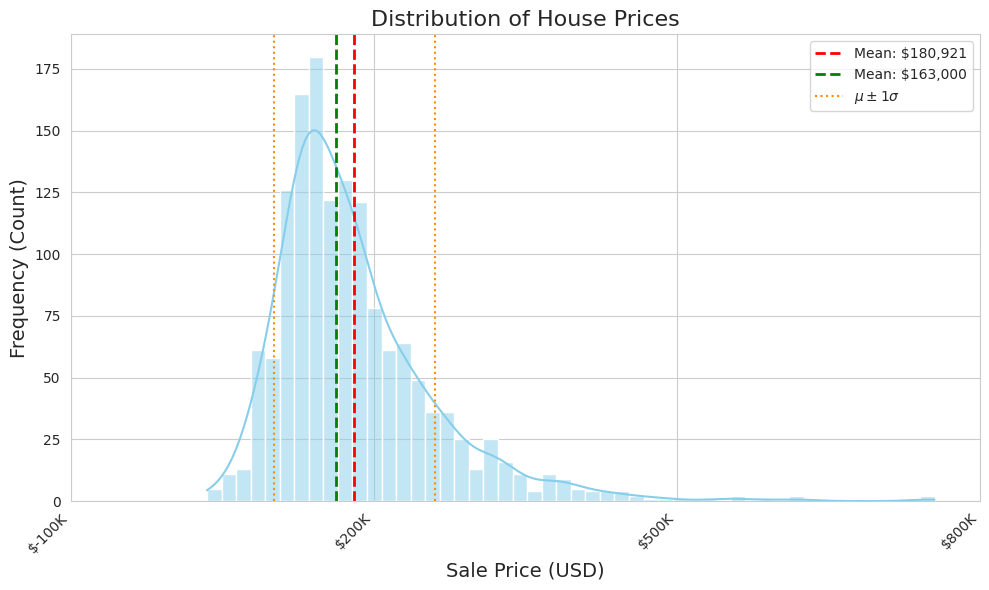

180921.19589041095
79442.50288288663
163000.0


In [5]:
#Distribution of house price
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of House Prices', fontsize=16)
plt.xlabel('Sale Price (USD)', fontsize=14)
plt.ylabel('Frequency (Count)', fontsize=14)
locs, labels = plt.xticks()
new_labels = [f'${x/1000:,.0f}K' for x in locs]
plt.xticks(locs[::3], new_labels[::3], rotation=45, ha='right')

mean_price = df['SalePrice'].mean()
median_price = df['SalePrice'].median()
std_price = df['SalePrice'].std()
plt.axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_price:,.0f}')
plt.axvline(median_price, color='green', linestyle='--', linewidth=2, label=f'Mean: ${median_price:,.0f}')
plt.axvline(mean_price + std_price, color='darkorange', linestyle=':', linewidth=1.5, label=r'$\mu \pm 1\sigma$')
plt.axvline(mean_price - std_price, color='darkorange', linestyle=':', linewidth=1.5)
plt.legend()
plt.tight_layout()
plt.show()
print(mean_price)
print(std_price)
print(median_price)



Calculated Upper Bound (Cap): 340,037.50
Number of high SalePrice outliers capped: 61
177331.52636986302
67205.83591480758
163000.0


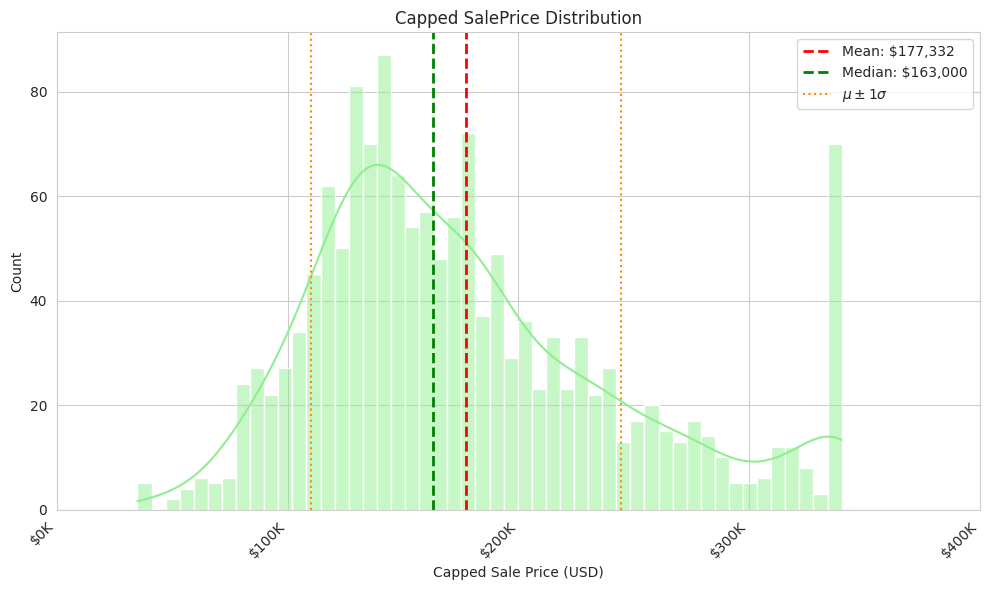

In [6]:
#outlier
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
num_capped = len(df[df['SalePrice'] > upper_bound])
df['SalePrice_outlier'] = df['SalePrice'].clip(lower=lower_bound, upper=upper_bound)
mean_outlier_price = df['SalePrice_outlier'].mean()
std_outlier_price = df['SalePrice_outlier'].std()
median_outlier_price = df['SalePrice_outlier'].median()

print(f"Calculated Upper Bound (Cap): {upper_bound:,.2f}")
print(f"Number of high SalePrice outliers capped: {num_capped}")

plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice_outlier'], kde=True, bins=50, color='lightgreen')
plt.title('Capped SalePrice Distribution')
plt.xlabel('Capped Sale Price (USD)')

plt.axvline(mean_outlier_price, color='red', linestyle='--', linewidth=2,
            label=f'Mean: ${mean_outlier_price:,.0f}')
plt.axvline(median_outlier_price, color='green', linestyle='--', linewidth=2,
            label=f'Median: ${median_outlier_price:,.0f}')
plt.axvline(mean_outlier_price + std_outlier_price, color='darkorange', linestyle=':', linewidth=1.5,
            label=r'$\mu \pm 1\sigma$')
plt.axvline(mean_outlier_price - std_outlier_price, color='darkorange', linestyle=':', linewidth=1.5)

locs, labels = plt.xticks()
new_labels = [f'${x/1000:,.0f}K' for x in locs]
plt.xticks(locs[::2], new_labels[::2], rotation=45, ha='right')

plt.legend()
plt.tight_layout()

print(mean_outlier_price)
print(std_outlier_price)
print(median_outlier_price)